# Example usage of `run_agent_env_sensor_loop`

This notebook shows a minimal, end-to-end call to `run_agent_env_sensor_loop`, including:
- setting sensor and specification parameters
- choosing whether to use pure PID or EKF+PID
- saving and viewing the trajectory plot

In [1]:
from pathlib import Path

# Ensure notebook is running from project root
project_root = Path.cwd()
project_root

PosixPath('/Users/andrewzchen/S-Senior/Winter Quarter/CS 238V/aa228v_finalproject')

In [2]:
import numpy as np
from main import run_agent_env_sensor_loop

In [ ]:
sensor_args = dict(
    # Wave amplitude
    mu_A=0.1,
    sigma_A=0.05,
    # Wave wavenumber
    mu_k=2 * np.pi,
    sigma_k=0.5,
    # Vibration
    sigma_eps=0.01,
    # LiDAR penetration
    p_penetration=0.05,
    alpha_min=0.10,
    alpha_max=10.0,
    perfect_sensing=False,
)

specification = dict(
    z_min=0.1,
    z_max=1.0,
    pitch_min=-np.deg2rad(15.0),
    pitch_max=np.deg2rad(15.0),
)

trajectory_path = "plane_trajectory_notebook.png"

In [ ]:
result = run_agent_env_sensor_loop(
    z0=0.5,
    z_target=0.5,
    n_steps=500,  # dt = 0.01 s
    seed=42,
    enable_lateral_damper=True,  # fixes lateral instability using aileron
    use_ekf_pid_controller=True,  # set False to run pure PID
    sensor_args=sensor_args,
    specification=specification,
    save_trajectory_plot=True,
    trajectory_plot_path=trajectory_path,
)

result

 step    z_true     z_hat    de_pid    de_ekf    da_ekf     z_est   theta_est
------------------------------------------------------------------------
Controller driving env.step: EKF+PID
    0    0.5000    0.4805    0.0078    0.0077   -0.0000    0.4807    -0.00000
   20    0.4417    0.5211   -0.0362   -0.0331    0.0014    0.5126     0.01385
   40    0.3679    0.4794   -0.0356   -0.0345    0.0031    0.4754     0.02204
   60    0.3189    0.3887   -0.0334   -0.0353    0.0041    0.3921     0.03943
   80    0.3228    0.2583    0.0088    0.0037    0.0046    0.2691     0.04471
  100    0.3571    0.2472    0.0012   -0.0014    0.0046    0.2513     0.05097
  120    0.4127    0.4025   -0.0545   -0.0520    0.0043    0.3940     0.04773
  140    0.4644    0.5952   -0.1141   -0.1359    0.0041    0.6465     0.03878
  160    0.4839    0.4978   -0.0487   -0.0532    0.0041    0.5062     0.02531
  180    0.4706    0.3682    0.0015   -0.0013    0.0042    0.3723     0.02601
  200    0.4568    0.5066   -0.0

{'terminated_early': False,
 'termination_step': None,
 'termination_type': None,
 'termination_message': None,
 'violated_spec': None,
 'final_state': array([ 5.60925263e-01, -2.98207589e-01,  9.21757231e+01,  1.98213362e+01,
         2.25298559e-02, -4.51183122e-02]),
 'used_ekf_pid': True,
 'specification': {'z_min': 0.1,
  'z_max': 1.0,
  'pitch_min': np.float64(-0.2617993877991494),
  'pitch_max': np.float64(0.2617993877991494)},
 'trajectory_plot': {'saved': True,
  'path': 'plane_trajectory_notebook.png',
  'num_points': 501}}

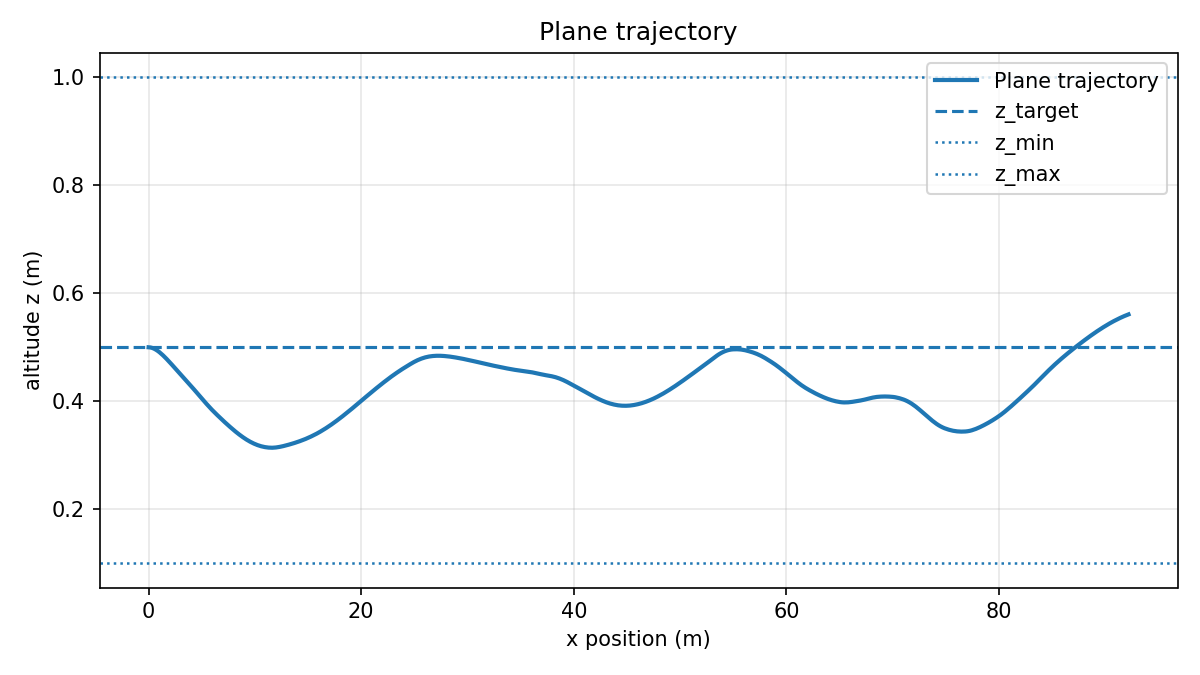

In [5]:
from IPython.display import Image, display

if result.get("trajectory_plot", {}).get("saved", False):
    display(Image(filename=result["trajectory_plot"]["path"]))
else:
    print("Trajectory plot was not saved.")
    print(result.get("trajectory_plot"))